**Get data**

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz") # It creates a path object pointing to: datasets/housing.tgz
    if not tarball_path.is_file(): # checks: Does datasets/housing.tgz exist?
        Path("datasets").mkdir(parents=True, exist_ok=True) # creates the folder /datasets
        url = "https://github.com/ageron/data/raw/main/housing.tgz" # download link, The file is a .tgz file which means: tar + gzip compressed archive(like a zip file)
        urllib.request.urlretrieve(url, tarball_path) # download the data from internet, from: https://github.com/ageron/data/raw/main/housing.tgz, to: datasets/housing.tgz 
        with tarfile.open(tarball_path) as housing_tarball: # opens the compressed file, example inside archive: housing/housing.csv
            housing_tarball.extractall(path="datasets", filter="data") # extract the archive into /datasets, filter: only extract files that contain "data" in their name, in this case: housing/housing.csv, after extraction datasets/housing/housing.csv will be created
    return pd.read_csv(Path("datasets/housing/housing.csv")) # load csv into pandas DataFrame, and return it

housing_full = load_housing_data()

**Data structure**

In [3]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
housing_full["ocean_proximity"].value_counts() # ["col"] - series(1 column), [["col"]] - dataframe(1 column table)

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [6]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


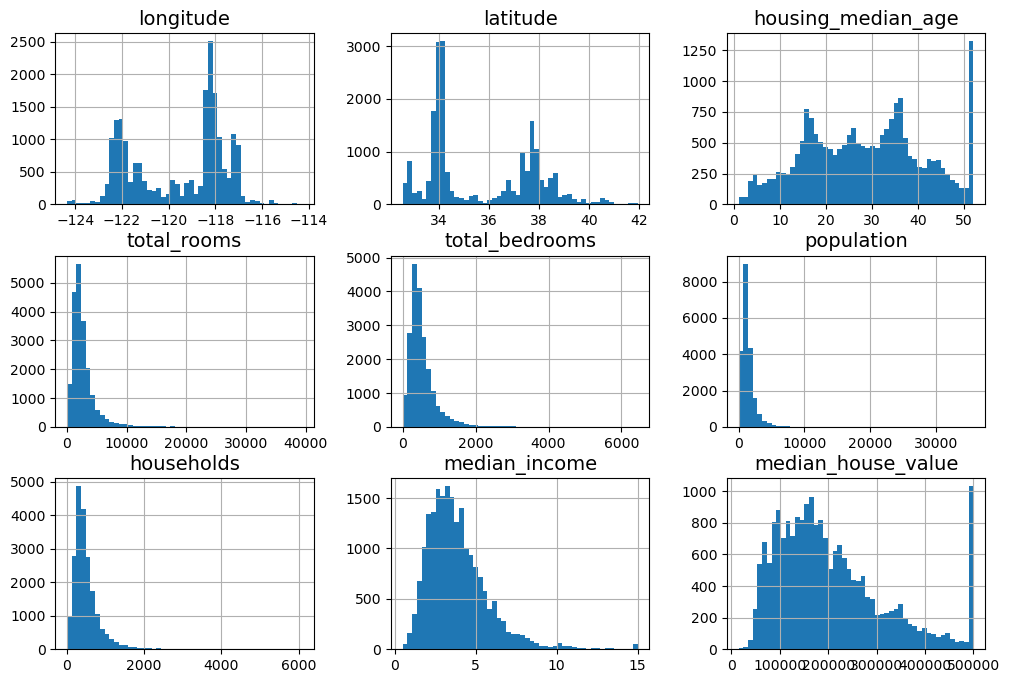

In [7]:
import matplotlib.pyplot as plt 

# default font sizes
plt.rc('font',  size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

housing_full.hist(bins=50, figsize=(12, 8)) # visualize distribution of every numerical column in dataset
# count(y-axis) vs value(x-axis) histogram 

plt.show()

**SEt test**

In [8]:
import numpy as np

def shuffle_and_split_data(data, test_ratio, rng):
    shuffled_indices = rng.permutation(len(data)) # shuffle the indices of the data
    test_set_size = int(len(data) * test_ratio) # calculate the size of the test set
    test_indices = shuffled_indices[:test_set_size] # get the indices for the test set
    train_indices = shuffled_indices[test_set_size:] # get the indices for the training set
    return data.iloc[train_indices], data.iloc[test_indices] # return the training and test sets


To ensure that this notebook's outputs remain the same every time we run it, we need to set the random seed:

In [9]:
rng = np.random.default_rng(seed=42) # create a random number generator with a fixed seed for reproducibility
train_set, test_set = shuffle_and_split_data(housing_full, test_ratio=0.2, rng=rng) 

len(train_set), len(test_set)

(16512, 4128)

Sadly, this won't guarantee that this notebook will output exactly the same results as in the book, since there are other possible sources of variation. The most important is the fact that algorithms get tweaked over time when libraries evolve. So please tolerate some minor differences: hopefully, most of the outputs should be the same, or at least in the right ballpark.

Note: another source of randomness is the order of Python sets: it is based on Python's `hash()` function, which is randomly `salted` when Python starts up (this started in Python 3.3, to prevent some denial-of-service attacks). To remove this randomness, the solution is to set the `PYTHONHASHSEED` environment variable to `0` before Python even starts up. Nothing will happen if you do it after that. Luckily, if you're running this notebook on Colab, the variable is already set for you.

In [10]:
from zlib import crc32 # 'crc32' is a hash function ~ It converts a value → 32-bit integer hash

def is_id_in_test_set(identifier, test_ratio): 
    """ 
    convert ID into int(64bit) that crc32 can hash  
    compare threshold with the hash value to decide if the data point should go to test set or not
    let 'test_ratio=0.2` 0.2 × 2^32 ≈ 858,993,459
    hash < 858,993,459  → test set
    otherwise           → train set 

    this ensure 20% of IDs go to test set
    """
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column): # pandas datafrem, % of data for test, column used as unique identifier
    ids = data[id_column] # 
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio)) # check if each row is test
    return data.loc[~in_test_set], data.loc[in_test_set] # split dataset

the housing dataset does not have an identifier column. The simplest solution is to use the row index as the ID

In [11]:
housing_with_id = housing_full.reset_index()  # adds an `index` column 
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index") 

this row indx will work as unique index if we don't delete any row and append the new data at the end of the dataset

We can also use latitude and longitude as this will not change 

In [12]:
housing_with_id["id"] = (housing_full["longitude"] * 1000 + housing_full["latitude"]) 
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id") 

The `train_test_split()` does the same thing as `shuffle_and_split_data()` with some additional feature 

In [13]:
# this does the same job
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing_full, test_size=0.2, random_state=42)

In [14]:
test_set["total_bedrooms"].isnull().sum()

44

To find the probability that a random sample of 1,000 people contains less than 49% female or more than 54% female when the population's female ratio is 51.6%, we use the `binomial distribution`. The `cdf()` method of the binomial distribution gives us the probability that the number of females will be equal or less than the given value.

In [15]:
#shows how to compute the 10.7% proba of getting a bad sample

from scipy.stats import binom

sample_size = 1000
ratio_female = 0.516
proba_too_small = binom(sample_size, ratio_female).cdf(490 - 1)
proba_too_large = 1 - binom(sample_size, ratio_female).cdf(540)
print(proba_too_small + proba_too_large)

0.10727422667455615


If you prefer simulations over maths, here's how you could get roughly the same result:

In [16]:
# shows another way to estimate the probability of bad sample

rng = np.random.default_rng(seed=42)
samples = (rng.random((100_000, sample_size)) < ratio_female).sum(axis=1)
((samples < 490) | (samples > 540)).mean()

0.1077

Creating an income category attribute as the median income is a contenious numerical attribute

In [17]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"],bins=[0., 1.5, 3.0, 4.5, 6., np.inf],labels=[1, 2, 3, 4, 5]) 
"""
pd.cut()~ convert continous data into categorical data
6-infinity → 5
4.5-6 → 4
3-4.5 → 3
1.5-3 → 2
0-1.5 → 1
"""

'\npd.cut()~ convert continous data into categorical data\n6-infinity → 5\n4.5-6 → 4\n3-4.5 → 3\n1.5-3 → 2\n0-1.5 → 1\n'

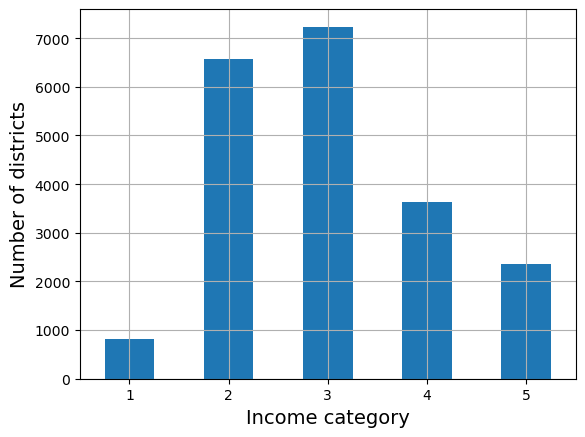

In [18]:
cat_counts = housing_full["income_cat"].value_counts().sort_index() # count how many district fall into each category, sort_index()~ appear in order not by frequency
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")

plt.show()

`split()` method yield on the training & test indices not on the data itself
, Having multiple splits can help in better estimation

In [19]:
from sklearn.model_selection import StratifiedShuffleSplit

**Here the code generated 10 different *straitified splits* of same dataset** 

In [20]:
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42) # create a splitter object that will split the data into 10 different train/test sets, with 20% of the data in the test set, and a fixed random state for reproducibility
strat_split = []

for train_index, test_index in splitter.split(housing_full, housing_full['income_cat']):
    strat_train_set_n = housing_full.iloc[train_index] # get the training set for this split
    strat_test_set_n = housing_full.iloc[test_index] # get the test set for this
    strat_split.append([strat_train_set_n, strat_test_set_n]) 


**Use the first split**

In [21]:
strat_train_set, strat_test_set = strat_split[0]

Shortcut is the `train_test_split()`

In [22]:
strat_train_set, strat_test_set = train_test_split(housing_full, test_size=0.2, stratify=housing_full["income_cat"], random_state=42)

In [23]:
strat_test_set['income_cat'].value_counts()/len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

*Here the `income_cat` is an **engineered, temporary column** which was created to perform `straitified sampling` , ensuring both `training` & `test` set has similar income distribution*

*so we'll not use this category `income_cat` as a feature in training* 

*Though we'll use `median_income` as a feature in training*

In [24]:
# Drop the column income_cat so the data is back to its original state
for set_ in (strat_train_set, strat_test_set):
    set_.drop('income_cat', axis=1, inplace=True)

### Visualize data

In [25]:
housing = strat_train_set.copy()

*As `longitude` & `latitude` is there visualaize the geographical data*

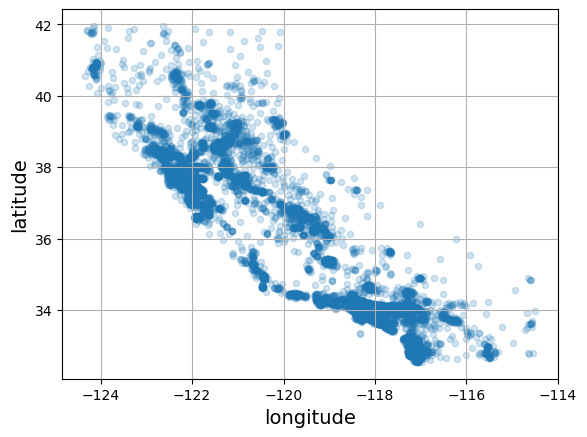

In [26]:
housing.plot(kind='scatter', x='longitude', y='latitude', grid=True, alpha=0.2) # alpha =0.2 help visualize the data 
plt.show()

*Now visualize the `housing price`*
- Radius of each circle represent the population
- Color blue to red represent price

<Axes: xlabel='longitude', ylabel='latitude'>

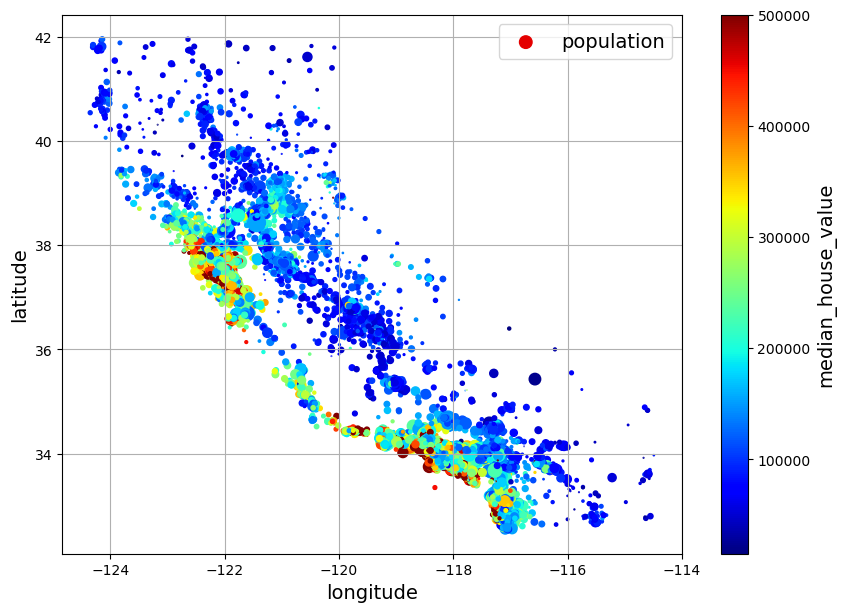

In [27]:
housing.plot(kind="scatter", x="longitude", y ="latitude", grid=True, s=housing['population']/100, label='population',c="median_house_value", cmap='jet', colorbar=True, legend=True, sharex=False, figsize=(10, 7))

*So the price is very much related to location & population density*

**Look for correlation**

*Between every numerical data*

In [28]:
corr_matrix = housing.corr(numeric_only=True)

*See correlation of each attribute with `median_house_value`*

In [29]:
corr_matrix['median_house_value'].sort_values(ascending=False)
# """
# 1 -> Strongly positive correlation 
# 0 -> NO linear correlation
# -1 -> Strongly negative correlation 
# """

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

*another way `pandas scatter_matrix()` function*

In [30]:
from pandas.plotting import scatter_matrix

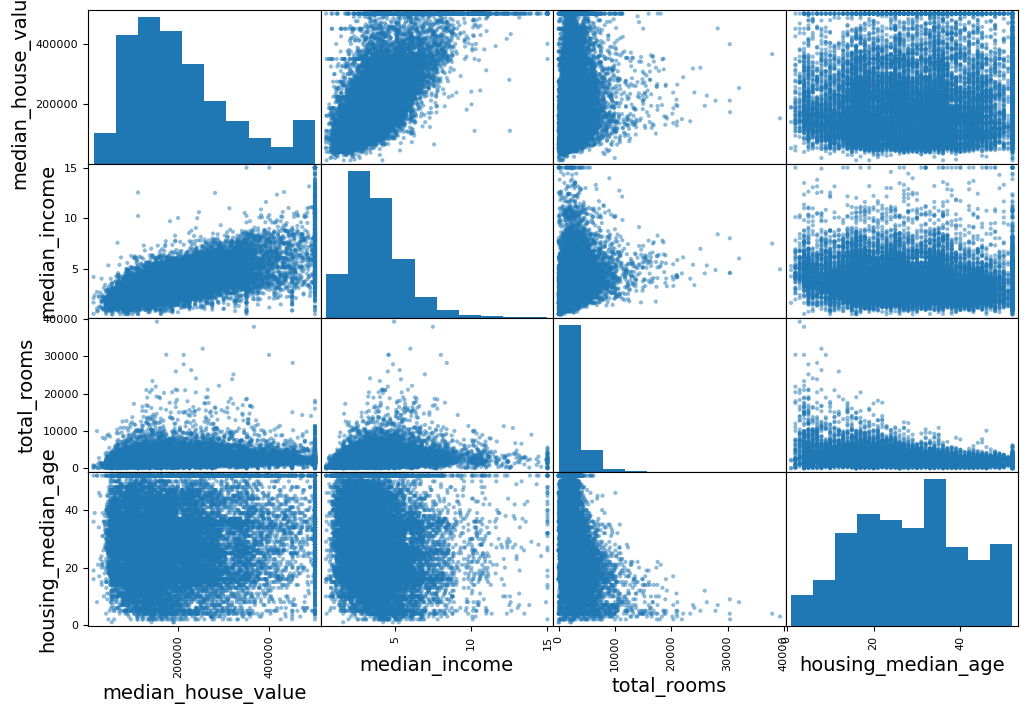

In [31]:
attributes = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']

scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

*It seems most promising promising attribute to predict the `median_house_value` is `median_income`* 

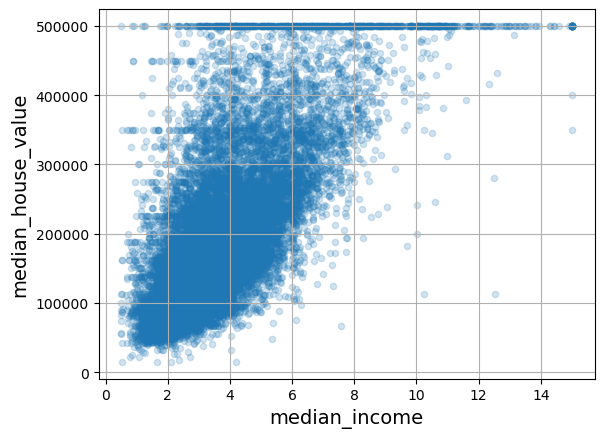

In [32]:
housing.plot(kind='scatter', x = "median_income", y="median_house_value", alpha=0.2, grid=True)
plt.show()

*This plot reveal many thing about the data the horizontal line  in $500000 also in $450000, $350000, $280000 & I would probably want to delete these data to avoide my algo from learning to reproduce these data quirks(roundings)*
- *These lines mean there are many data points with the same target value*
- *First it's not natural data, the $500k is most likely the upper limit, any house with value more than $500k is considered as $500k - the true reltionship is destroyed*
- *Model will learn wrong pattern*
- *The other lines mean ~ price was rounded, or grouped or capped at multiple round - these are not real world continuous value*

*Removing these data keep only clean data & model learn actual pattern*

*Attribute combinatories*

*Create new attributes*

In [33]:
housing['rooms_per_household'] = housing['total_rooms'] / housing['households']
housing['bedroom_ratio'] = housing['total_bedrooms'] / housing['total_rooms']
housing['people_per_house'] = housing['population'] / housing['households']

*correlation matrix*

In [34]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value     1.000000
median_income          0.688380
rooms_per_household    0.143663
total_rooms            0.137455
housing_median_age     0.102175
households             0.071426
total_bedrooms         0.054635
population            -0.020153
people_per_house      -0.038224
longitude             -0.050859
latitude              -0.139584
bedroom_ratio         -0.256397
Name: median_house_value, dtype: float64

*So the new `bedroom_ratio` is more correlated with `median_house_value` than the `total no of rooms or bedroom` strong neg correlation*

*This step is not mandetory but u can do, & it's a iterative process*

### Preapering data for ML algo

In [35]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set['median_house_value'].copy()

***Clean the data***

In [36]:
# housing.dropna(subset=['total_bedrooms'], inplace=True)
#or
# housing.drop("total_bedrooms", axis=1, inplace=True) 
#or
# median = housing['total_bedrooms'].median()
# housing['total_bedrooms'].fillna(median, inplace=True) # replace null values with median value

*We'll use `SimpleImputer` class*

In [37]:
from sklearn.impute import SimpleImputer
impute = SimpleImputer(strategy='median') # this store the missing value of each feature, impute not only in training data but also validation, test fed to the model

***since the median can only be of numerical value we'll create a numerical data & impute***

In [38]:
housing_num = housing.select_dtypes(include=[np.number])

In [39]:
impute.fit(housing_num)

SimpleImputer(strategy='median')

***Imputer has stored the result in it's `statistic_instance` variable***

*Only the `total_bedrooms` has null value, but we can't be sure there will be no missing value in new data after sys goes live, so it's safer to apply `imputer` to all numerical attribute*

In [40]:
impute.statistics_ # the median value of each feature

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [41]:
housing_num.median().values # the same result as impute.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

*Now we can use trained `impute` to transform the training data by replacing missing value with learned median*

In [42]:
x = impute.transform(housing_num)

*Missing value acn also be replaced by*
- "mean"
- "most_frequent"
- "constant", fill_value=...

***There are more imputers (for numerical feature)***
- *KNNImputer ~ replace missing value  with mean of K nearest neighbour*
- *IterativeImputer ~ Train a regression model to predict the missing value based on all other available features, it again train the model on updated value, repeats the process several time improving the model performance & the missing value upon each iteration*

*Transformer output `numpy` array even when give pandas dataframe as input, so the `X` here is a numpy array with no index & column name*

In [43]:
housing_tr = pd.DataFrame(x, columns=housing_num.columns, index = housing_num.index)    

**Handling Text & Categorical data**

In [44]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head()

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN


*So it's not arbitrary text but categorical attribute*

*Turn this into number*

In [45]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
housing_cat_encoded = oe.fit_transform(housing_cat)

In [46]:
housing_cat_encoded[:10]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.],
       [0.],
       [0.]])

In [47]:
oe.categories_ # categories using `categories` instance variable

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

*Now the ML algo will assume two nearby values are more similar than two distance values, but this's not true here, so the solution is `binary attribute`*

In [48]:
from sklearn.preprocessing import OneHotEncoder
cat_encode = OneHotEncoder()
housing_cat_1hot = cat_encode.fit_transform(housing_cat)

*Here the output is a `Scipy sparse matrix`, sparse matrix is a efficient representation of matrix containing mostly `0`*

*Internally stores the `non-zero` value & it's position*

can also use pandas `get_dummies` func but 1HE is more memory efficient & it remember on which categories it was trained on

**Feature scaling & Transformation**

*So here the total `room number` range from 6 to 39320 & `median incomes` only range from 0 to 15 so the model will be biased toward `room number` without any scaling*

*Ways to get the scale of the attributes same are*
- Min-Max scaling (Normalization) ~ *values shifted & rescaled so that they range between 0 & 1, it has `feature_range` hyperparameter to change range*
- Standardization ~ *much less affected by outliers, shift the std to , doesn't restrict values to a specific range*

In [49]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1, 1))
housing_min_max_scaled = scaler.fit_transform(housing_num)

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
housing_num_std_scalar = scaler.fit_transform(housing_num) 
"""
If apply this on a sparse matrix will apply with the hyperparameter `with_mean=False` which will divide the data by std without substracting the mean, because sparse matrix cannot be centered.
"""

'\nIf apply this on a sparse matrix will apply with the hyperparameter `with_mean=False` which will divide the data by std without substracting the mean, because sparse matrix cannot be centered.\n'

***So if a feature's distribution has a heavy tail(many value far from `mean`) before scaling we should transform this to shrink the heavy tail & if possible make the distribution roughly symmetric***

*Replacing the feature with it's `log` may help if the feature has a really long tail*

*Another approach is `bucketing the feature`* 

~ Chop the distribution in equal size bucket & replace each feature value with each bucket index

~ Multimodal dist. (with 2 or more clear peaks) - same way 

~ M D - Add a feature for each of the modes, representing the similarity b/w the feature value & the mode, measured by the function `radial bias function`(any func that depends on the distance b/w i/p value & the fixed point) 

*Here is an example of measuring the similarity b/w `housing median age` & the point `35` using `Gaussian RBF`*

In [51]:
from sklearn.metrics.pairwise import rbf_kernel
age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

***Target value Transformation***

*So we use `log_transform` now the model predict `log(price)` instead of `price` directly, so we now `inverse(exponential)` the log to get the price value*
- This way the value get compressed 
- Relationship become more linear

In [52]:
# Example
from sklearn.linear_model import LinearRegression
target_scale = StandardScaler()

scaled_labels = target_scale.fit_transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
some_new_data = housing[['median_income']].iloc[:5] 

scaled_prediction = model.predict(some_new_data)
predictions = target_scale.inverse_transform(scaled_prediction)

In [ ]:
# TransformedTarget Regressor is simpler & less error prone
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(regressor=LinearRegression(), transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)

predictions = model.predict(some_new_data)  # use the scaler's inverse_transform() method automatically

**Custom Transformer**

*Let us create custom transformer, Here is an example of `log_transformation`*
- FT can take hyperparameter as additional argument 
- Combine features

In [ ]:
from sklearn.preprocessing import FunctionTransformer
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp) # `inverse_func` is used to specify the inverse transformation function, in this case, the exponential function which is the inverse of the logarithm function. This allows us to easily transform the data back to its original scale after applying the log transformation.
log_pop = log_transformer.fit_transform(housing[["population"]])

***What if I want my `transformer` to be trainable, learn some parameter in `fit()` method & use them later in `transform()` method, Here we need to write `custom class`***

***Custom Transformer*** don't need to inherit from from base class, just need 3 methods `fit()`, `transform()` & `fit_transform()`

*Adding `TransformerMixin` as base class we can use `fit_transform()` for free*

*If use `BaseEstimator` as base class & don't use `*args & **kwargs` we get 2 extra parameters `get_params()` & `set_params()` which help in automatically tuning hyperparameter*

In [55]:
# Custom transformer that act like StandardScaler 
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):
        self.with_mean=with_mean
    def fit(self, x, y=None): # y is required for compatibility with pipelines, but it is not used in this transformer
        x = check_array(x) # check if x is array with finite float value

        self.mean_ = x.mean(axis=0)
        self.scale_ = x.std(axis=0)
        self.n_features_in_ = x.shape[1] # every estimator stores this in  

        return self
    
    def transform(self, x):
        check_is_fitted(self) # check if the transformer is fitted before transforming the data # looks for learned attributes (with trailing_)

        x = check_array(x)
        assert self.n_features_in_ == x.shape[1]
        if self.with_mean:
            x = x - self.mean_
        return x/self.scale_

**Transformation Pipeline**

*Example* of a numerical attribute, 1st impute then scale the feature

In [ ]:
from sklearn.pipeline import Pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

*If don't use the estimator name/ transformer can use the `make_pipeline()` func, it take transformer as positional arg & create pipeline using name of the transformer class*

*If multiple transformers are there with same name then index is appended to their name*

In [ ]:
from sklearn.pipeline import make_pipeline

make_pipeline =([
    (SimpleImputer(strategy='median')),
    (StandardScaler())
])

$\color{red}{\text{Estimator is the model or any object that learn from data using .fit()}}$

### Select & train Model